In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Άσκηση - Φίλτρα κυλιόμενης μέσης τιμής 3, 5 και 7 σημείων: επίδραση στις συνιστώσες αθροίσματος ημιτόνων

Στην Άσκηση αυτή μελετάμε το κλασικό φίλτρο **κυλιόμενης μέσης τιμής (Moving Average, MA)** — ένα γραμμικό, χρονικά αμετάβλητο (LTI) σύστημα διακριτού χρόνου τύπου **FIR** — και εξετάζουμε πώς η επιλογή του **μήκους** του ($L=3,5,7$) καθορίζει σε ποιες συχνότητες επηρεάζεται το σήμα εισόδου. 

Θα το εφαρμόσουμε σε μια είσοδο που αποτελείται από **τρία ημίτονα** διαφορετικής συχνότητας και θα δούμε ότι κάθε μήκος $L$ εξαφανίζει **ακριβώς μία** από τις τρεις συνιστώσες.

### Το φίλτρο στο πεδίο του χρόνου

Χρησιμοποιούμε τη **συμμετρική (μη-αιτιατή)** εκδοχή μήκους $L$ (με $L$ περιττό και $M=\tfrac{L-1}{2}$), ώστε το φίλτρο να έχει **μηδενική φάση**:

$$ y[n] = \frac{1}{L}\sum_{k=-M}^{M} x[n-k] \tag{1}$$

Ειδικότερα, για τα τρία μήκη που μας ενδιαφέρουν:

$$ y_3[n] = \tfrac{1}{3}\big(x[n+1]+x[n]+x[n-1]\big) \tag{2}$$

$$ y_5[n] = \tfrac{1}{5}\big(x[n+2]+x[n+1]+x[n]+x[n-1]+x[n-2]\big) \tag{3}$$

$$ y_7[n] = \tfrac{1}{7}\sum_{k=-3}^{3} x[n-k] \tag{4}$$

Σε κάθε περίπτωση η κρουστική απόκριση είναι ένας **παλμός πλάτους** $1/L$ και μήκους $L$: $$h[n]=\tfrac{1}{L}$$ για $|n|\le M$, αλλιώς $0$.

### Το φίλτρο στο πεδίο της συχνότητας

Επειδή το σύστημα είναι LTI, ένα καθαρό ημίτονο εισόδου παραμένει ημίτονο **ίδιας** συχνότητας στην έξοδο, απλώς πολλαπλασιασμένο κατά το πλάτος της απόκρισης συχνότητας:

$$ x[n]=\cos(\omega_0 n) \;\longrightarrow\; y[n]=|H(\omega_0)|\,\cos\big(\omega_0 n + \angle H(\omega_0)\big) \tag{5}$$

Η απόκριση συχνότητας προκύπτει αθροίζοντας τα εκθετικά της Σχέσης (1). Λόγω συμμετρίας, τα φανταστικά μέρη αλληλοαναιρούνται και μένει ένα **άθροισμα συνημιτόνων** (πραγματική συνάρτηση):

$$ H(\omega) = \frac{1}{L}\sum_{k=-M}^{M} e^{-j\omega k} = \frac{1}{L}\left(1 + 2\sum_{k=1}^{M}\cos(k\omega)\right) \tag{6}$$

Το άθροισμα αυτό έχει γνωστή κλειστή μορφή (πυρήνας **Dirichlet**):

$$ H(\omega) = \frac{1}{L}\,\frac{\sin(L\omega/2)}{\sin(\omega/2)} \tag{7}$$

Στο $\omega=0$ ισχύει $H(0)=1$ (η μέση τιμή περνά ανέπαφη): το MA φίλτρο είναι **βαθυπερατό** (lowpass). Επειδή $H(\omega)$ είναι **πραγματική**, η φάση είναι $0$ (όπου $H>0$) ή $\pi$ (όπου $H<0$, δηλαδή αναστροφή προσήμου).

### Οι μηδενισμοί (zeros) της συχνοτικής απόκρισης

Το κρίσιμο σημείο: η $H(\omega)$ **μηδενίζεται** όποτε ο αριθμητής $\sin(L\omega/2)$ μηδενίζεται χωρίς να μηδενίζεται ο παρονομαστής, δηλαδή

$$ \frac{L\omega}{2}=m\pi \;\Rightarrow\; \omega = \frac{2\pi m}{L}, \quad m=1,2,\dots,L-1 \tag{8}$$

Άρα, στο διάστημα $(0,\pi]$:

* $L=3$: μηδενισμός στο $\omega=\tfrac{2\pi}{3}$
* $L=5$: μηδενισμοί στα $\omega=\tfrac{2\pi}{5},\ \tfrac{4\pi}{5}$
* $L=7$: μηδενισμοί στα $\omega=\tfrac{2\pi}{7},\ \tfrac{4\pi}{7},\ \tfrac{6\pi}{7}$

**Ερμηνεία:** αν η συχνότητα μιας ημιτονοειδούς συνιστώσας πέσει **ακριβώς** πάνω σε έναν μηδενισμό, τότε $|H(\omega_0)|=0$ και η συνιστώσα **εξαφανίζεται πλήρως**. Αν πέσει κοντά σε μηδενισμό, αποδυναμώνεται έντονα· αν πέσει κοντά στο $\omega=0$, περνά σχεδόν ανέπαφη.

### Η είσοδος: άθροισμα τριών ημιτόνων

Επιλέγουμε επίτηδες τις τρεις συχνότητες ώστε καθεμία να συμπίπτει με έναν μηδενισμό **διαφορετικού** φίλτρου:

$$ x[n] = \cos(\omega_1 n) + \cos(\omega_2 n) + \cos(\omega_3 n), \qquad \omega_1=\tfrac{2\pi}{7},\ \omega_2=\tfrac{2\pi}{5},\ \omega_3=\tfrac{2\pi}{3} \tag{9}$$

Με βάση τη Σχέση (8) περιμένουμε: το **7-σημείων** σβήνει την $\omega_1$, το **5-σημείων** σβήνει την $\omega_2$, και το **3-σημείων** σβήνει την $\omega_3$.

### i. Κατασκευή και απεικόνιση της εισόδου

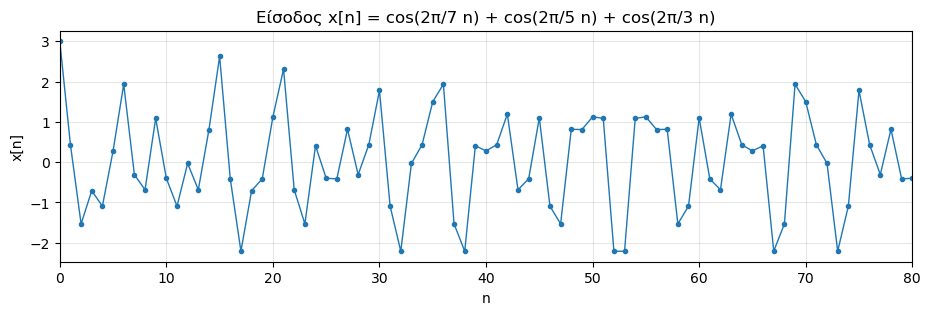

In [2]:
N = 210
n = np.arange(N)
w1, w2, w3 = 2*np.pi/7, 2*np.pi/5, 2*np.pi/3
x = np.cos(w1*n) + np.cos(w2*n) + np.cos(w3*n)

plt.figure(figsize=(11, 3))
plt.plot(n, x, '-o', ms=3, lw=1)
plt.title('Είσοδος x[n] = cos(2π/7 n) + cos(2π/5 n) + cos(2π/3 n)')
plt.xlabel('n'); plt.ylabel('x[n]'); plt.grid(True, alpha=0.3)
plt.xlim(0, 80); plt.show()

### ii. Σκελετός κώδικα — υλοποίηση του MA μήκους $L$

Θεωρούμε το σήμα ως 1D ακολουθία και το διατρέχουμε σε παράθυρα $L$ σημείων, με μετατόπιση ένα δείγμα. Γιατί ο βρόχος ξεκινά από `M` και σταματά στο `N-M`;

    def moving_average(x, L):
        M = (L - 1) // 2
        y = np.zeros_like(x)
        for i in range(M, len(x) - M):   # γιατί όχι 0..N-1;
            win = x[i-M : i+M+1]          # παράθυρο L σημείων
            y[i] = ############          # Σχέση (1)
        return y, M

Επιτρέπεται η χρήση **μόνο** των $\textrm{sum}$ / $\textrm{mean}$.

**Υλοποίηση και εφαρμογή των τριών φίλτρων στο πεδίο του χρόνου**

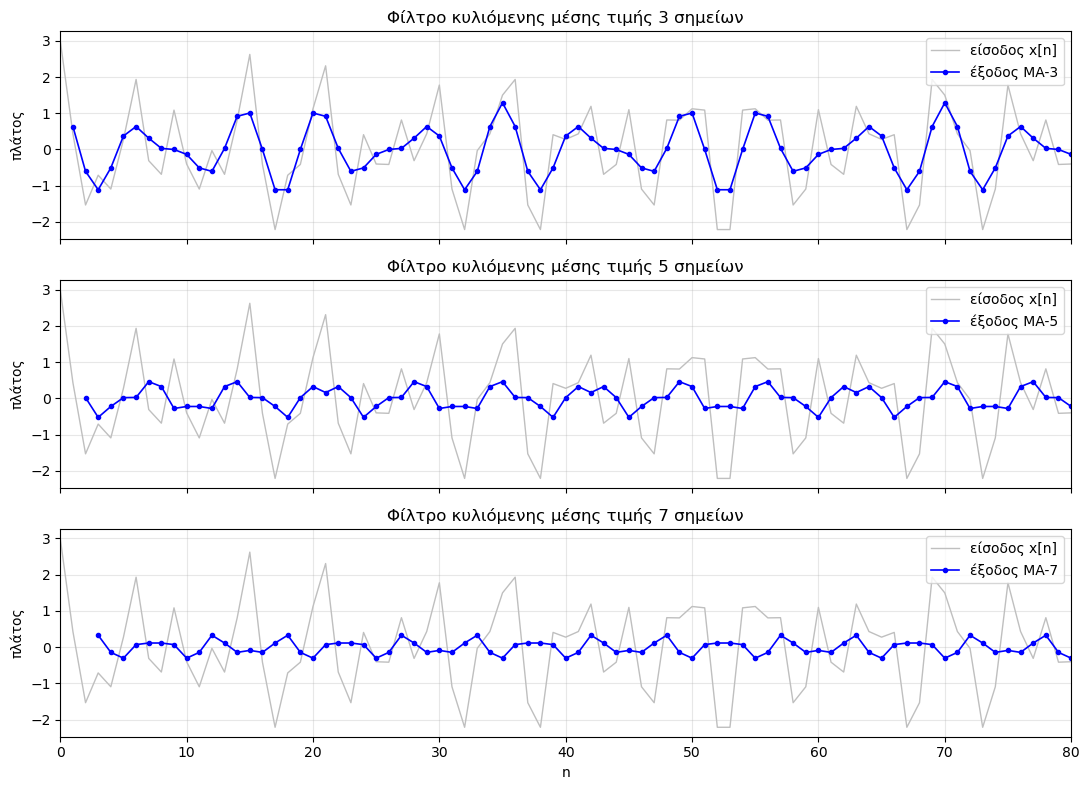

In [7]:
def moving_average(x, L):
    M = (L - 1) // 2
    y = np.zeros_like(x, dtype=float)
    for i in range(M, len(x) - M):        # άκρα: δεν υπάρχει πλήρες παράθυρο
        y[i] = np.mean(x[i-M : i+M+1])
    return y, M

fig, ax = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

for row, L in enumerate([3, 5, 7]):
    y, M = moving_average(x, L)
    ax[row].plot(n, x, color='0.75', lw=1, label='είσοδος x[n]')
    ax[row].plot(n[M:N-M], y[M:N-M], 'b-o', ms=3, lw=1.2, label=f'έξοδος MA-{L}')
    ax[row].set_title(f'Φίλτρο κυλιόμενης μέσης τιμής {L} σημείων')
    ax[row].set_ylabel('πλάτος'); ax[row].grid(True, alpha=0.3)
    ax[row].legend(loc='upper right'); ax[row].set_xlim(0, 80)

ax[-1].set_xlabel('n')
plt.tight_layout(); plt.show()

### iii. Απόκριση συχνότητας και θέση των συνιστωσών

Σχεδιάζουμε το $|H(e^{j\omega})|$ κάθε φίλτρου (μέσω της Σχέσης (6), αθροίσματος συνημιτόνων) και σημειώνουμε πού βρίσκονται οι τρεις συχνότητες της εισόδου.

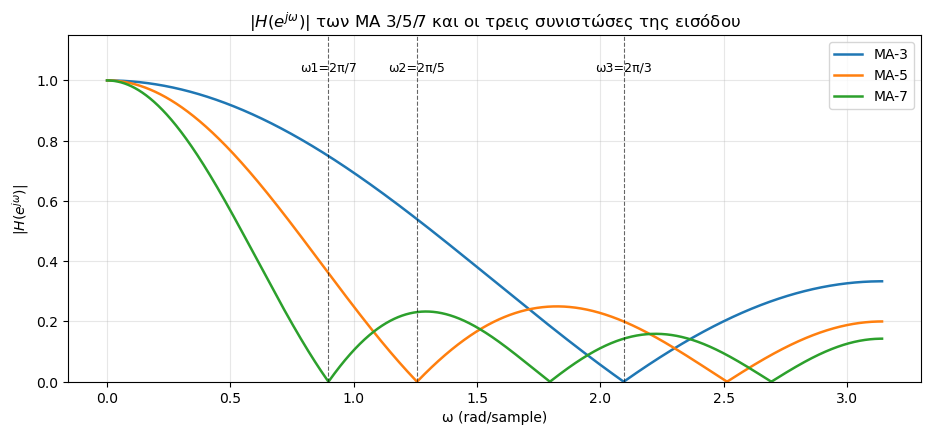

In [13]:
def H(w, L):
    M = (L - 1) // 2
    s = np.ones_like(w)
    for k in range(1, M + 1):
        s = s + 2*np.cos(k*w)          # Σχέση (6): 1 + 2 Σ cos(kω)
    return s / L

w = np.linspace(0, np.pi, 2000)
comp = {'ω1=2π/7': w1, 'ω2=2π/5': w2, 'ω3=2π/3': w3}
colors = {3: 'tab:blue', 5: 'tab:orange', 7: 'tab:green'}

plt.figure(figsize=(11, 4.5))
for L in [3, 5, 7]:
    plt.plot(w, np.abs(H(w, L)), color=colors[L], lw=1.8, label=f'MA-{L}')
for name, wc in comp.items():
    plt.axvline(wc, color='k', ls='--', lw=0.8, alpha=0.6)
    plt.text(wc, 1.02, name, rotation=0, va='bottom', ha='center', fontsize=9)
plt.title('$|H(e^{jω})|$ των MA 3/5/7 και οι τρεις συνιστώσες της εισόδου')
plt.xlabel('ω (rad/sample)'); plt.ylabel('$|H(e^{jω})|$')
plt.grid(True, alpha=0.3); plt.legend(loc='upper right'); plt.ylim(0, 1.15)
plt.show()

### iv. Ποσοτικοποίηση: κέρδος κάθε φίλτρου σε κάθε συνιστώσα

Υπολογίζουμε το (προσημασμένο) κέρδος $H(\omega_i)$. Τιμή $0$ σημαίνει πλήρη εξάλειψη, ενώ αρνητική τιμή σημαίνει αναστροφή φάσης κατά $\pi$.

In [16]:
import numpy as np
print(f"{'':8s}{'ω1=2π/7':>12s}{'ω2=2π/5':>12s}{'ω3=2π/3':>12s}")

for L in [3, 5, 7]:
    g = [float(H(np.array([wc]), L)[0]) for wc in [w1, w2, w3]]
    print(f'MA-{L:<5d}' + ''.join(f'{v:>12.3f}' for v in g))

             ω1=2π/7     ω2=2π/5     ω3=2π/3
MA-3           0.749       0.539       0.000
MA-5           0.360       0.000      -0.200
MA-7           0.000      -0.231       0.143


### v. Επαλήθευση: η φιλτραρισμένη έξοδος ισούται με το άθροισμα των **επιζώντων** συνιστωσών

Αφού το φίλτρο είναι LTI, η έξοδος πρέπει να ισούται με $\sum_i |H(e^{j\omega_i})|\cos(\omega_i n + \angle H(e^{j\omega_i}))$. Το επιβεβαιώνουμε αριθμητικά (στην έγκυρη περιοχή, μακριά από τα άκρα).

In [18]:
for L in [3, 5, 7]:
    y, M = moving_average(x, L)

    yhat = sum(float(H(np.array([wc]), L)[0]) * np.cos(wc*n) for wc in [w1, w2, w3])
    
    err = np.max(np.abs(y[M:N-M] - yhat[M:N-M]))

    killed = [nm for nm, wc in zip(['ω1','ω2','ω3'], [w1, w2, w3]) if abs(float(H(np.array([wc]), L)[0])) < 1e-9]
    
    print(f'MA-{L}:  max|y - yhat| = {err:.2e}   -> εξαλείφεται η συνιστώσα {killed}')

MA-3:  max|y - yhat| = 2.32e-14   -> εξαλείφεται η συνιστώσα ['ω3']
MA-5:  max|y - yhat| = 1.90e-14   -> εξαλείφεται η συνιστώσα ['ω2']
MA-7:  max|y - yhat| = 1.30e-14   -> εξαλείφεται η συνιστώσα ['ω1']


### Παρατηρήσεις

Το φίλτρο κυλιόμενης μέσης τιμής είναι βαθυπερατό ($H(e^{j0})=1$), αλλά η απόκρισή του **δεν** είναι μονότονη: εμφανίζει **μηδενισμούς** στις συχνότητες $\omega_m=2\pi m/L$. 

Επειδή διαλέξαμε τις τρεις συχνότητες της εισόδου να πέφτουν ακριβώς πάνω στους μηδενισμούς διαφορετικών φίλτρων, το αποτέλεσμα είναι «καθαρό»: το MA-3 σβήνει πλήρως την $\omega_3=2\pi/3$, το MA-5 την $\omega_2=2\pi/5$ και το MA-7 την $\omega_1=2\pi/7$ (πίνακας του βήματος iv — μηδενικά κελιά). 

Οι υπόλοιπες συνιστώσες περνούν με μειωμένο πλάτος, και όπου το $H(e^{j\omega_i})$ είναι αρνητικό (π.χ. MA-5 στην $\omega_3$) υπάρχει **αναστροφή φάσης** κατά $\pi$. Το βήμα v. επιβεβαιώνει (σφάλμα $\sim 10^{-15}$) ότι η έξοδος είναι ακριβώς το άθροισμα των συνιστωσών που περνούν από το φίλτρο, όπως προβλέπει η LTI θεωρία της Σχέσης (5).

Το γενικότερο συμπέρασμα: αυξάνοντας το μήκος του φίλτρου, $L$, πυκνώνουν τα σημεία μηδενισμού και στενεύει η ζώνη διέλευσης (ισχυρότερη εξομάλυνση), ενώ η θέση των σημείων μηδενισμού μας επιτρέπει να «στοχεύσουμε» και να αφαιρέσουμε συγκεκριμένες περιοδικές ενοχλήσεις. Αυτό αποτελεί μια πρώτη γεύση του σχεδιασμού φίλτρων μέσα από τη συχνοτική απόκριση.

---
---